🎮 Predictor de Mobs de Minecraft


✅ Modelo cargado: C:/Users/Usuario/OneDrive - IUE/SEMESTRE 2025-2/IA II/Dataset/minecraft_mob_classifier_final(portatil_cnn).h5
🎯 Clases: ['aldeanos', 'creepers', 'vacas']

📸 Imagen: 2025-09-24_08.03.45.png
🎯 Predicción: vacas
🎲 Confianza: 100.00%

📊 Todas las probabilidades:
  aldeanos: 0.00%
  creepers: 0.00%
  vacas: 100.00%


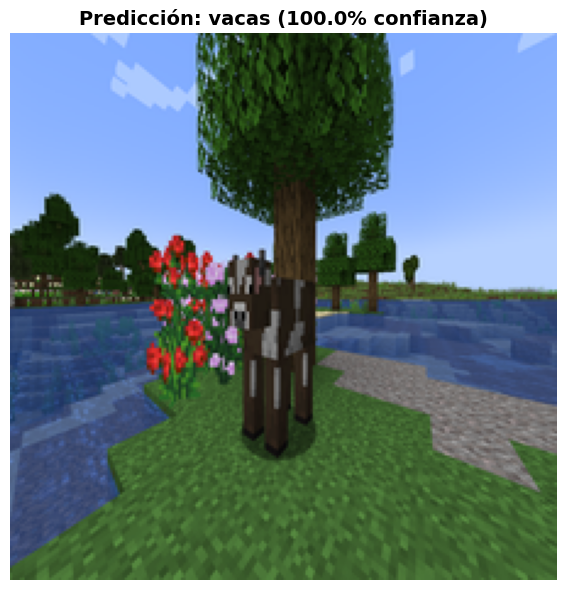


📸 Imagen: 2025-09-24_08.03.45.png
🎯 Predicción: vacas
🎲 Confianza: 100.00%

📊 Todas las probabilidades:
  aldeanos: 0.00%
  creepers: 0.00%
  vacas: 100.00%

💡 Para usar:
  predictor.predict_and_show('tu_imagen.png')
  predictor.batch_predict('carpeta_imagenes/')


In [9]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from PIL import Image
import os

class MinecraftPredictor:
    def __init__(self, model_path, class_names=None):
        """
        Inicializa el predictor de mobs
        model_path: ruta al modelo .h5 entrenado
        class_names: lista de nombres de clases (si no se proporciona, usa orden alfabético)
        """
        self.model = keras.models.load_model(model_path)
        self.img_size = 224  # Tamaño usado en entrenamiento
        
        # Nombres de clases (ajusta según tu orden)
        if class_names is None:
            self.class_names = ['aldeanos', 'creepers', 'vacas']  # Orden alfabético típico
        else:
            self.class_names = class_names
            
        print(f"✅ Modelo cargado: {model_path}")
        print(f"🎯 Clases: {self.class_names}")
        
    def preprocess_image(self, image_path):
        """Preprocesa una imagen para predicción"""
        # Carga la imagen
        img = Image.open(image_path).convert('RGB')
        
        # Redimensiona a 224x224 (mismo tamaño del entrenamiento)
        img = img.resize((self.img_size, self.img_size), Image.LANCZOS)
        
        # Convierte a array y normaliza (0-1)
        img_array = np.array(img) / 255.0
        
        # Añade dimensión de batch
        img_array = np.expand_dims(img_array, axis=0)
        
        return img_array, img
        
    def predict_single(self, image_path):
        """Predice la clase de una sola imagen"""
        try:
            # Preprocesa la imagen
            img_array, original_img = self.preprocess_image(image_path)
            
            # Hace la predicción
            predictions = self.model.predict(img_array, verbose=0)
            
            # Obtiene la clase predicha y confianza
            predicted_class_idx = np.argmax(predictions[0])
            confidence = predictions[0][predicted_class_idx]
            predicted_class = self.class_names[predicted_class_idx]
            
            # Muestra resultados
            print(f"\n📸 Imagen: {os.path.basename(image_path)}")
            print(f"🎯 Predicción: {predicted_class}")
            print(f"🎲 Confianza: {confidence:.2%}")
            
            # Muestra todas las probabilidades
            print("\n📊 Todas las probabilidades:")
            for i, class_name in enumerate(self.class_names):
                prob = predictions[0][i]
                print(f"  {class_name}: {prob:.2%}")
                
            return predicted_class, confidence, original_img
            
        except Exception as e:
            print(f"❌ Error procesando {image_path}: {str(e)}")
            return None, None, None
            
    def predict_and_show(self, image_path):
        """Predice y muestra la imagen con resultado"""
        predicted_class, confidence, img = self.predict_single(image_path)
        
        if img is not None:
            plt.figure(figsize=(8, 6))
            plt.imshow(img)
            plt.title(f'Predicción: {predicted_class} ({confidence:.1%} confianza)', 
                     fontsize=14, fontweight='bold')
            plt.axis('off')
            plt.tight_layout()
            plt.show()
            
    def batch_predict(self, images_folder):
        """Predice múltiples imágenes de una carpeta"""
        supported_formats = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
        
        image_files = []
        for ext in supported_formats:
            image_files.extend([f for f in os.listdir(images_folder) 
                              if f.lower().endswith(ext)])
        
        if not image_files:
            print("❌ No se encontraron imágenes en la carpeta")
            return
            
        print(f"🔍 Encontradas {len(image_files)} imágenes")
        print("-" * 50)
        
        results = []
        for img_file in image_files:
            img_path = os.path.join(images_folder, img_file)
            predicted_class, confidence, _ = self.predict_single(img_path)
            if predicted_class:
                results.append({
                    'archivo': img_file,
                    'prediccion': predicted_class,
                    'confianza': confidence
                })
        
        # Resumen
        print(f"\n📋 Resumen de {len(results)} predicciones:")
        for result in results:
            print(f"  {result['archivo']}: {result['prediccion']} ({result['confianza']:.1%})")
            
        return results


def main():
    # Configuración
    MODEL_PATH = "C:/Users/Usuario/OneDrive - IUE/SEMESTRE 2025-2/IA II/Dataset/minecraft_mob_classifier_final(portatil_cnn).h5"  # Tu modelo entrenado
    CLASS_NAMES = ['aldeanos', 'creepers', 'vacas']    # Ajusta según tu orden
    
    print("🎮 Predictor de Mobs de Minecraft")
    print("=" * 40)
    
    # Inicializa el predictor
    try:
        predictor = MinecraftPredictor(MODEL_PATH, CLASS_NAMES)
    except Exception as e:
        print(f"❌ Error cargando modelo: {e}")
        return
    
    # Ejemplos de uso:
    
    # 1. Predice una imagen específica
    predictor.predict_and_show("2025-09-24_08.03.45.png")
    
    # 2. Predice solo y muestra resultados en texto
    predictor.predict_single("2025-09-24_08.03.45.png")
    
    # 3. Predice todas las imágenes de una carpeta
    # predictor.batch_predict("imagenes_prueba/")
    
    print("\n💡 Para usar:")
    print("  predictor.predict_and_show('tu_imagen.png')")
    print("  predictor.batch_predict('carpeta_imagenes/')")


if __name__ == "__main__":
    main()